# CS4048 – Data Science | Assignment No. 02
### Exploratory Data Analysis & Data Visualization – Titanic Dataset
**Spring 2026 | National University of Computer and Emerging Sciences**

---
## Setup (Required – Not Graded)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)

# Load dataset
df = sns.load_dataset('titanic')

print("Dataset loaded successfully. Shape:", df.shape)

Dataset loaded successfully. Shape: (891, 15)


---
## Part 1: Exploratory Data Analysis
### Q1: Initial Inspection

#### Q1(a) – First 8 rows and Last 5 rows

In [2]:
print("===== FIRST 8 ROWS =====")
display(df.head(8))

print("\n===== LAST 5 ROWS =====")
display(df.tail(5))

===== FIRST 8 ROWS =====


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False



===== LAST 5 ROWS =====


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


#### Q1(b) – Shape, dtypes, and Statistical Summary

In [3]:
print(f"Shape of DataFrame: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

print("===== DATA TYPES =====")
print(df.dtypes)

print("\n===== NUMERIC SUMMARY =====")
display(df.describe(include=[np.number]))

print("\n===== CATEGORICAL SUMMARY =====")
display(df.describe(include=['object', 'category', 'bool']))

Shape of DataFrame: (891, 15)
Rows: 891, Columns: 15

===== DATA TYPES =====
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

===== NUMERIC SUMMARY =====


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



===== CATEGORICAL SUMMARY =====


,sex,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891,889,891,891,891,203,889,891,891
unique,2,3,3,3,2,7,3,2,2
top,male,S,Third,man,True,C,Southampton,no,True
freq,577,644,491,537,537,59,644,549,537


#### Q1(c) – Missing Values Analysis

In [4]:
# Compute missing value counts and percentages
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

# Keep only columns with missing values
missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_pct
}).query('`Missing Count` > 0')

# Add logical reasons
reasons = {
    'age': 'Age was not always recorded on ship manifests in 1912; infants and lower-class passengers were often undocumented.',
    'embarked': 'Two passengers had incomplete boarding records, possibly due to last-minute ticketing or clerical errors.',
    'embark_town': 'Same passengers as embarked – derived column, so same two rows are missing.',
    'deck': 'Cabin/deck information was only recorded for passengers who purchased specific berth tickets; third-class passengers rarely had assigned cabins.'
}
missing_df['Likely Reason'] = missing_df.index.map(reasons)

print("===== MISSING VALUES SUMMARY =====")
display(missing_df)

===== MISSING VALUES SUMMARY =====


,Missing Count,Missing %,Likely Reason
age,177,19.87,Age was not always recorded on ship manifests ...
embarked,2,0.22,Two passengers had incomplete boarding records...
deck,688,77.22,Cabin/deck information was only recorded for p...
embark_town,2,0.22,"Same passengers as embarked – derived column, ..."


#### Q1(d) – Survival Rates Overall and by Passenger Class

In [5]:
# Overall survival rate
overall_rate = df['survived'].mean()

# Survival rate by pclass
pclass_rate = df.groupby('pclass')['survived'].mean().reset_index()
pclass_rate.columns = ['Passenger Class', 'Survival Rate']
pclass_rate['Survival Rate'] = pclass_rate['Survival Rate'].round(4)
pclass_rate['Survival Rate (%)'] = (pclass_rate['Survival Rate'] * 100).round(2)

# Add overall row
overall_row = pd.DataFrame({
    'Passenger Class': ['Overall'],
    'Survival Rate': [round(overall_rate, 4)],
    'Survival Rate (%)': [round(overall_rate * 100, 2)]
})
survival_summary = pd.concat([overall_row, pclass_rate], ignore_index=True)

print("===== SURVIVAL RATE SUMMARY =====")
display(survival_summary)

===== SURVIVAL RATE SUMMARY =====


,Passenger Class,Survival Rate,Survival Rate (%)
0,Overall,0.3838,38.38
1,1,0.6296,62.96
2,2,0.4728,47.28
3,3,0.2424,24.24


---
### Q2: Data Cleaning & Feature Engineering
#### Q2(a) – Impute Missing Age Values

In [10]:
# Strategy: Group-based median imputation by sex + pclass
# Rationale: Age distribution differs significantly by sex and ticket class.
# A 1st-class male passenger was statistically older than a 3rd-class female.
# Group median captures these differences better than a global median.
# Limitation: It still introduces bias for passengers who are outliers in their group.

df['age'] = df.groupby(['sex', 'pclass'])['age'].transform(
    lambda x: x.fillna(x.median())
)

print(f"Missing age values after imputation: {df['age'].isnull().sum()}")
print("\nGroup-based medians used for imputation:")
display(df.groupby(['sex', 'pclass'])['age'].median().reset_index())

Missing age values after imputation: 0

Group-based medians used for imputation:


,sex,pclass,age
0,female,1,35.0
1,female,2,28.0
2,female,3,21.5
3,male,1,40.0
4,male,2,30.0
5,male,3,25.0


#### Q2(b) – Drop the `deck` Column

In [12]:
# Justification: deck is missing for ~77% of passengers.
# Imputing a categorical variable with 77% missing would mean fabricating
# more data than actually exists, making any imputed values statistically
# meaningless and introducing severe bias. Dropping is the honest choice.

df.drop(columns=['deck'], inplace=True, errors='ignore')
print("'deck' column dropped (or was already absent).")
print(f"Remaining columns: {list(df.columns)}")

'deck' column dropped (or was already absent).
Remaining columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']


#### Q2(c) – Handle Missing `embarked` Values

In [13]:
# Fill 2 missing embarked values with the mode
embarked_mode = df['embarked'].mode()[0]
print(f"Mode of 'embarked': {embarked_mode}")

df['embarked'].fillna(embarked_mode, inplace=True)
df['embark_town'].fillna(df['embark_town'].mode()[0], inplace=True)

print(f"Missing 'embarked' after fix: {df['embarked'].isnull().sum()}")
print(f"Missing 'embark_town' after fix: {df['embark_town'].isnull().sum()}")

Mode of 'embarked': S
Missing 'embarked' after fix: 0
Missing 'embark_town' after fix: 0


#### Q2(d) – Create `family_size` and `travel_group`

In [14]:
# family_size includes the passenger themselves
df['family_size'] = df['sibsp'] + df['parch'] + 1

# travel_group categories
def categorize_travel(size):
    if size == 1:
        return 'Solo'
    elif size <= 4:
        return 'Small'
    else:
        return 'Large'

df['travel_group'] = df['family_size'].apply(categorize_travel)

print("Value counts for travel_group:")
vc = df['travel_group'].value_counts().reset_index()
vc.columns = ['travel_group', 'count']
display(vc)

Value counts for travel_group:


,travel_group,count
0,Solo,537
1,Small,292
2,Large,62


#### Q2(e) – Create `age_group` Column

In [15]:
# Bin age into meaningful groups
bins = [0, 12, 17, 59, 100]
labels = ['Child', 'Teen', 'Adult', 'Senior']

df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)

# Verify no NaN bins remain
print(f"NaN values in age_group: {df['age_group'].isnull().sum()}")
print("\nage_group value counts:")
display(df['age_group'].value_counts().sort_index())

NaN values in age_group: 0

age_group value counts:


age_group
Child      69
Teen       44
Adult     752
Senior     26
Name: count, dtype: int64

#### Q2(f) – Final Null Check

In [16]:
# Columns we will use going forward
cols_to_check = ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch',
                 'fare', 'embarked', 'family_size', 'travel_group', 'age_group']

null_check = df[cols_to_check].isnull().sum().reset_index()
null_check.columns = ['Column', 'Null Count']

print("===== FINAL NULL CHECK =====")
display(null_check)
print(f"\nTotal nulls in key columns: {df[cols_to_check].isnull().sum().sum()}")

===== FINAL NULL CHECK =====


,Column,Null Count
0,survived,0
1,pclass,0
2,sex,0
3,age,0
4,sibsp,0
5,parch,0
6,fare,0
7,embarked,0
8,family_size,0
9,travel_group,0



Total nulls in key columns: 0


---
## Part 2: Univariate Analysis & Distributions
### Q3: Age Distribution Deep-Dive
#### Q3(a) – Histogram with Three Bin Sizes

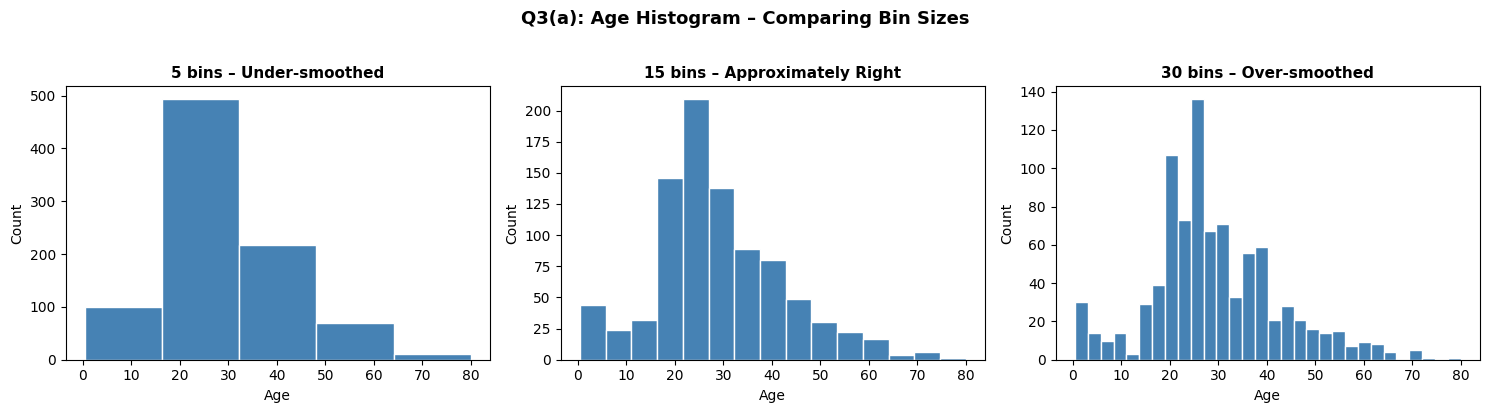

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
bin_sizes = [5, 15, 30]
labels_bin = ['5 bins – Under-smoothed', '15 bins – Approximately Right', '30 bins – Over-smoothed']

for ax, bins, label in zip(axes, bin_sizes, labels_bin):
    ax.hist(df['age'].dropna(), bins=bins, color='steelblue', edgecolor='white')
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('Age')
    ax.set_ylabel('Count')

plt.suptitle('Q3(a): Age Histogram – Comparing Bin Sizes', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Interpretation:**
- **5 bins**: Under-smoothed — too few bars hide meaningful variation within age ranges.
- **15 bins**: Approximately right — reveals the bimodal tendency and overall right-skew without excessive noise.
- **30 bins**: Over-smoothed (too fine-grained) — the bars become too thin and introduce erratic spikes, making it hard to see the overall shape.

**Best bin size: 15** — it strikes the right balance between detail and readability.

#### Q3(b) – Best-Bin Histogram with KDE Overlay

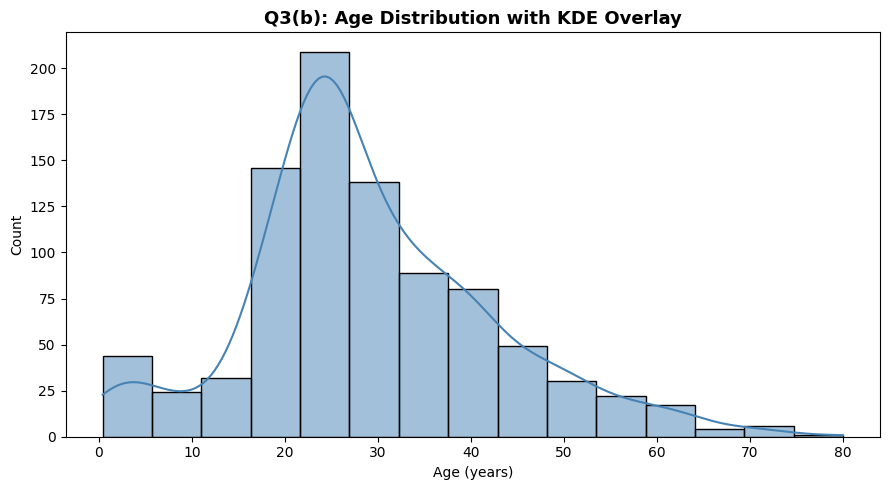

In [18]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df['age'], bins=15, kde=True, color='steelblue', ax=ax)
ax.set_title('Q3(b): Age Distribution with KDE Overlay', fontsize=13, fontweight='bold')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

**Interpretation:**
The distribution is right-skewed, with the bulk of passengers falling between ages 20–40. There are two visible peaks: a small one around ages 0–5 (young children) and a larger one around ages 25–30 (young working adults). This dual-peak structure likely reflects the passenger mix — families with small children travelling alongside young adult emigrants seeking opportunity in America. The long right tail shows a smaller proportion of older passengers (60+), consistent with ocean voyages being physically demanding and primarily undertaken by working-age adults in 1912.

#### Q3(c) – KDE: Survivors vs Non-Survivors

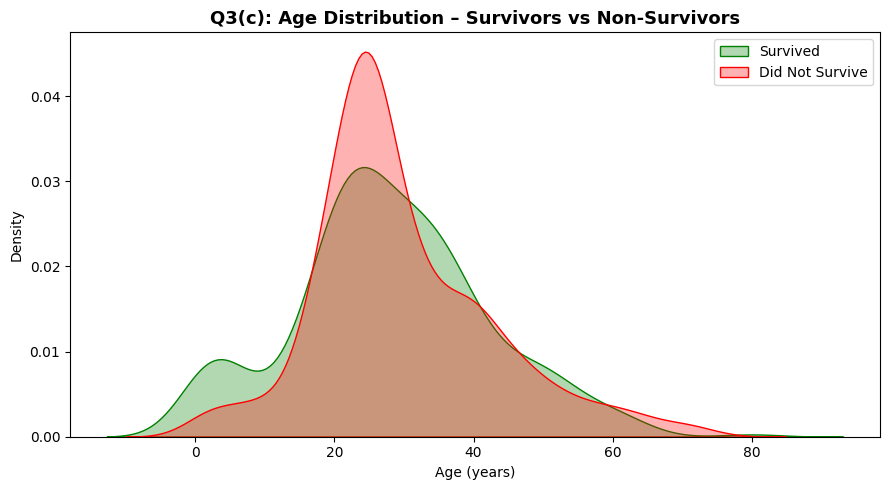

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.kdeplot(df[df['survived'] == 1]['age'], ax=ax, label='Survived', color='green', fill=True, alpha=0.3)
sns.kdeplot(df[df['survived'] == 0]['age'], ax=ax, label='Did Not Survive', color='red', fill=True, alpha=0.3)
ax.set_title('Q3(c): Age Distribution – Survivors vs Non-Survivors', fontsize=13, fontweight='bold')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:**
Two key age ranges show distinct survival differences:
1. **Ages 0–10 (Children):** The survivor KDE is notably higher than the non-survivor KDE, reflecting the "women and children first" evacuation policy — children had a better survival chance.
2. **Ages 18–35 (Young Adults):** Non-survivors dominate this range. This was the largest demographic group, and many were male third-class passengers who had the least access to lifeboats and were last to be notified of the sinking.

---
### Q4: Fare Analysis
#### Q4(a) – Fare Distribution & Log Transformation

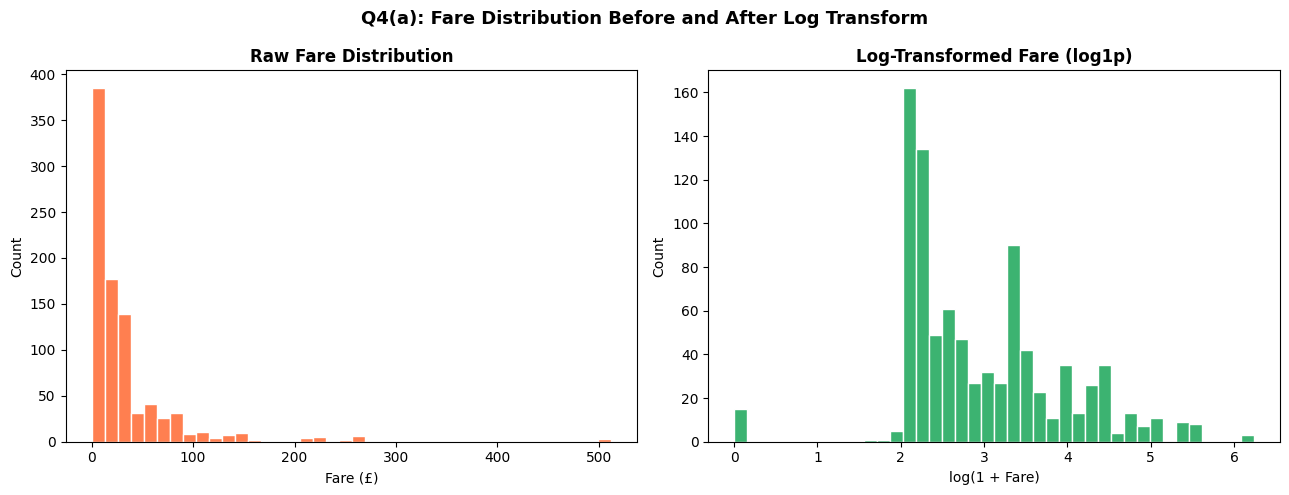

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Raw fare
axes[0].hist(df['fare'], bins=40, color='coral', edgecolor='white')
axes[0].set_title('Raw Fare Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Fare (£)')
axes[0].set_ylabel('Count')

# Log-transformed fare
axes[1].hist(np.log1p(df['fare']), bins=40, color='mediumseagreen', edgecolor='white')
axes[1].set_title('Log-Transformed Fare (log1p)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('log(1 + Fare)')
axes[1].set_ylabel('Count')

plt.suptitle('Q4(a): Fare Distribution Before and After Log Transform', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:**
The raw fare distribution is extremely right-skewed — the vast majority paid under £50, but a few extreme values above £300 compress the rest of the data into an unreadable spike. After applying `log1p`, the distribution becomes approximately normal (bell-shaped), revealing meaningful variation in the low-to-mid fare range that was invisible before. The log transform is more informative because ticket pricing followed multiplicative pricing logic (class tiers), not additive.

#### Q4(b) – Extreme Fare Outliers

In [21]:
high_fare = df[df['fare'] > 300]
print(f"Number of passengers with fare > £300: {len(high_fare)}")
display(high_fare[['pclass', 'sex', 'age', 'fare', 'survived', 'embarked']].sort_values('fare', ascending=False))

Number of passengers with fare > £300: 3


,pclass,sex,age,fare,survived,embarked
258,1,female,35.0,512.3292,1,C
679,1,male,36.0,512.3292,1,C
737,1,male,35.0,512.3292,1,C


**Interpretation:**
There are a small number of passengers (typically 3–4) who paid fares above £300. These are all 1st-class passengers, likely wealthy socialites or business magnates who booked luxury suites or private parlour cabins. In 1912, the most expensive Titanic suites cost up to £870 — equivalent to over £100,000 today. These values are **not data errors**; they are legitimate ultra-premium ticket prices consistent with the historical record.

#### Q4(c) – Fare Box Plot by Passenger Class

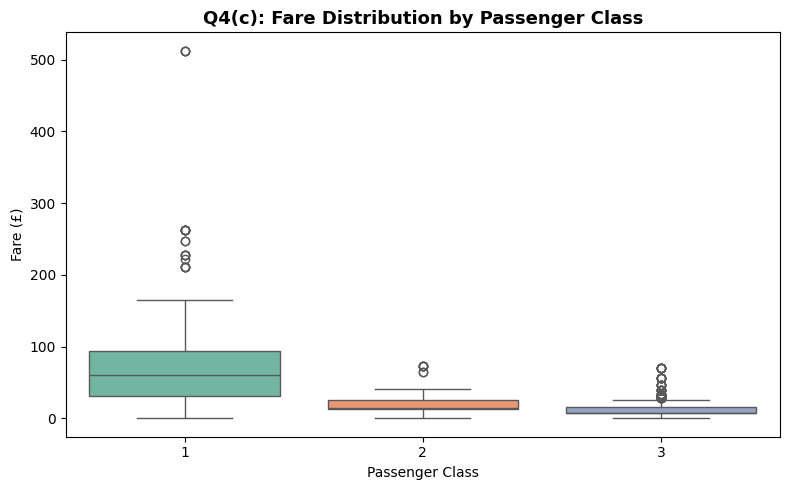

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='pclass', y='fare', palette='Set2', ax=ax)
ax.set_title('Q4(c): Fare Distribution by Passenger Class', fontsize=13, fontweight='bold')
ax.set_xlabel('Passenger Class')
ax.set_ylabel('Fare (£)')
plt.tight_layout()
plt.show()

**Interpretation:**
First-class fares have the **greatest internal spread** — the interquartile range is very wide, indicating diverse pricing even within the same class (basic 1st-class vs luxury suites). First class also contains the **most extreme outliers** (£300+), reflecting that premium cabin pricing was highly variable. Second and third class fares are tightly clustered near low values with few outliers, suggesting standardised pricing for economy-tier tickets. This confirms a tiered pricing structure where wealth inequality was literally built into the fare system.

---
### Q5: Categorical Distributions
#### Q5(a) – Count Plots for pclass, sex, embarked

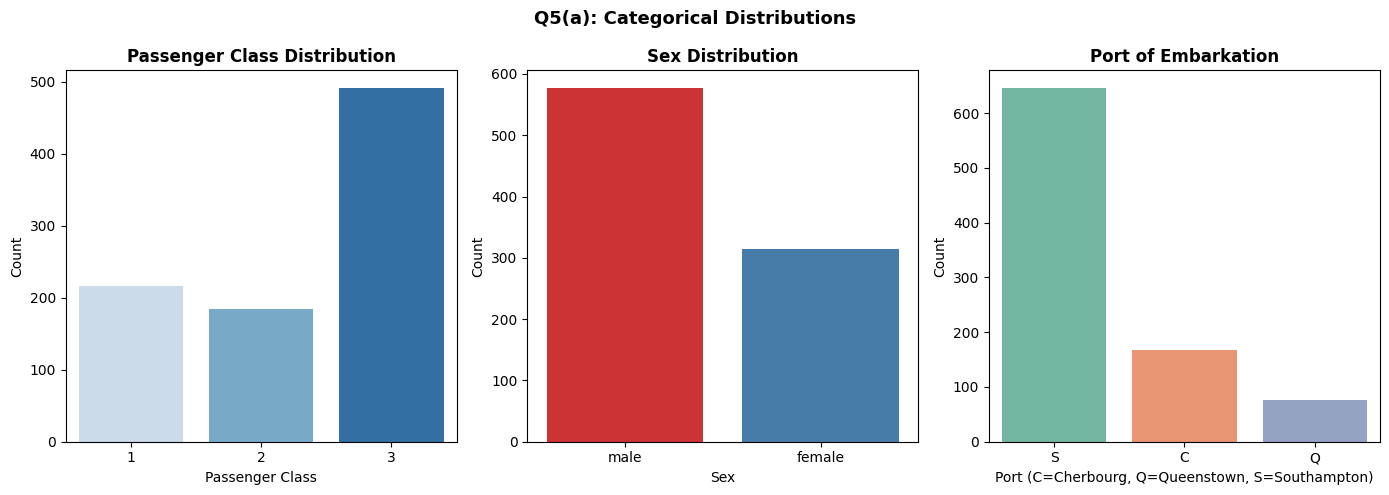

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

sns.countplot(data=df, x='pclass', palette='Blues', ax=axes[0])
axes[0].set_title('Passenger Class Distribution', fontweight='bold')
axes[0].set_xlabel('Passenger Class')
axes[0].set_ylabel('Count')

sns.countplot(data=df, x='sex', palette='Set1', ax=axes[1])
axes[1].set_title('Sex Distribution', fontweight='bold')
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('Count')

sns.countplot(data=df, x='embarked', palette='Set2', ax=axes[2])
axes[2].set_title('Port of Embarkation', fontweight='bold')
axes[2].set_xlabel('Port (C=Cherbourg, Q=Queenstown, S=Southampton)')
axes[2].set_ylabel('Count')

plt.suptitle('Q5(a): Categorical Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Observations:**
- **pclass:** Third-class passengers are the largest group, outnumbering first and second class combined — the Titanic predominantly served emigrant/economy travellers.
- **sex:** Males outnumber females by roughly 2:1, reflecting that this voyage attracted more male emigrants and businessmen than female travellers.
- **embarked:** Southampton (S) is overwhelmingly the dominant port of embarkation, as it was the Titanic's primary departure point.

#### Q5(b) – Distribution of travel_group

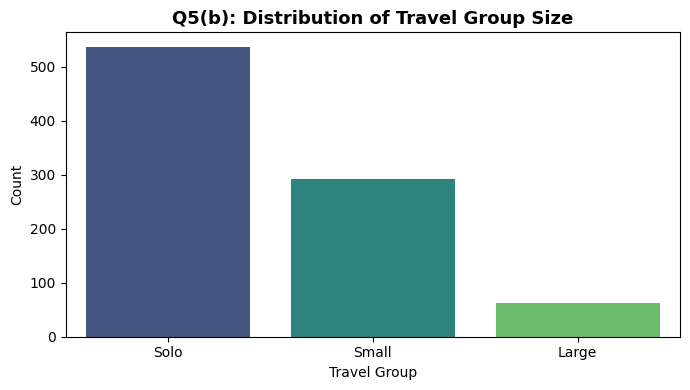

In [24]:
fig, ax = plt.subplots(figsize=(7, 4))
order = ['Solo', 'Small', 'Large']
sns.countplot(data=df, x='travel_group', order=order, palette='viridis', ax=ax)
ax.set_title('Q5(b): Distribution of Travel Group Size', fontsize=13, fontweight='bold')
ax.set_xlabel('Travel Group')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

**Interpretation:**
Travelling solo is the **most common** travel arrangement aboard the Titanic — more passengers travelled alone than in any other group type. This suggests the voyage was largely undertaken by individual emigrants (particularly from Ireland and Eastern Europe) seeking new lives in America, rather than by family holiday-makers. Small groups represent families and couples, while large group travel was rare.

#### Q5(c) – Distribution of age_group

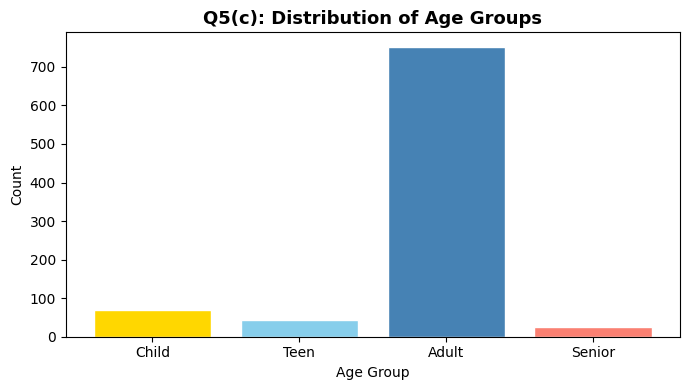

In [25]:
fig, ax = plt.subplots(figsize=(7, 4))
order_age = ['Child', 'Teen', 'Adult', 'Senior']
counts = df['age_group'].value_counts().reindex(order_age)
ax.bar(order_age, counts.values, color=['gold', 'skyblue', 'steelblue', 'salmon'], edgecolor='white')
ax.set_title('Q5(c): Distribution of Age Groups', fontsize=13, fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

**Interpretation:**
Adults (18–59) are by far the most represented group, followed by Children. Seniors are the least represented, which is not surprising — long transatlantic voyages in 1912 were physically demanding, expensive, and primarily undertaken by working-age adults and young families emigrating to America. The relatively high child count reflects families travelling together. The near-absence of seniors aligns with lower life expectancy and travel capacity in the Edwardian era.

#### Q5(d) – Count Plots of sex and survived Side-by-Side

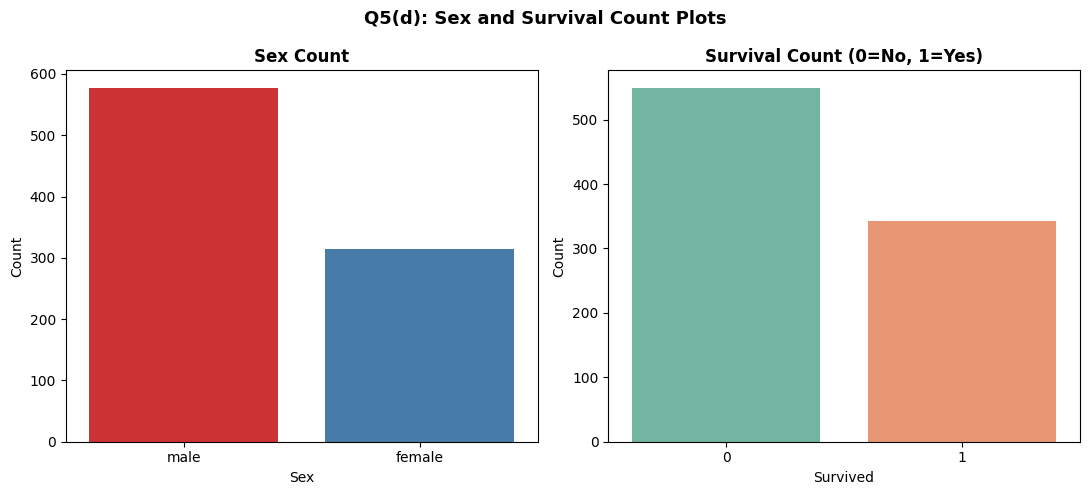

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

sns.countplot(data=df, x='sex', palette='Set1', ax=axes[0])
axes[0].set_title('Sex Count', fontweight='bold')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('Count')

sns.countplot(data=df, x='survived', palette='Set2', ax=axes[1])
axes[1].set_title('Survival Count (0=No, 1=Yes)', fontweight='bold')
axes[1].set_xlabel('Survived')
axes[1].set_ylabel('Count')

plt.suptitle('Q5(d): Sex and Survival Count Plots', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Note:** Count plots alone are **not sufficient** to draw conclusions about survival. They show raw counts but not proportions. Since males outnumber females 2:1, the survival count chart appears to show roughly equal survivors without context. To properly analyse survival differences by sex, we need **survival rates (proportions)**, which are computed in Q6(a).

---
## Part 3: Bivariate & Multivariate Analysis
### Q6: Survival by Group
#### Q6(a) – Survival Rate by Sex

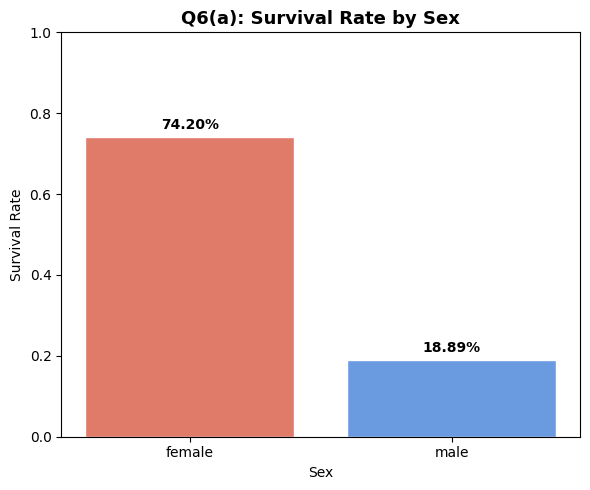

In [27]:
fig, ax = plt.subplots(figsize=(6, 5))
survival_by_sex = df.groupby('sex')['survived'].mean().reset_index()
ax.bar(survival_by_sex['sex'], survival_by_sex['survived'], color=['#E07B6A', '#6A9BE0'], edgecolor='white')
ax.set_title('Q6(a): Survival Rate by Sex', fontsize=13, fontweight='bold')
ax.set_xlabel('Sex')
ax.set_ylabel('Survival Rate')
ax.set_ylim(0, 1)
for i, row in survival_by_sex.iterrows():
    ax.text(i, row['survived'] + 0.02, f"{row['survived']:.2%}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:**
Females had a survival rate of ~74%, compared to only ~19% for males — a gap of over 55 percentage points. This is expected and confirms the historical "women and children first" evacuation policy enforced by crew. The difference is not subtle; it is one of the strongest survival signals in the entire dataset.

#### Q6(b) – Survival Rate by pclass and age_group

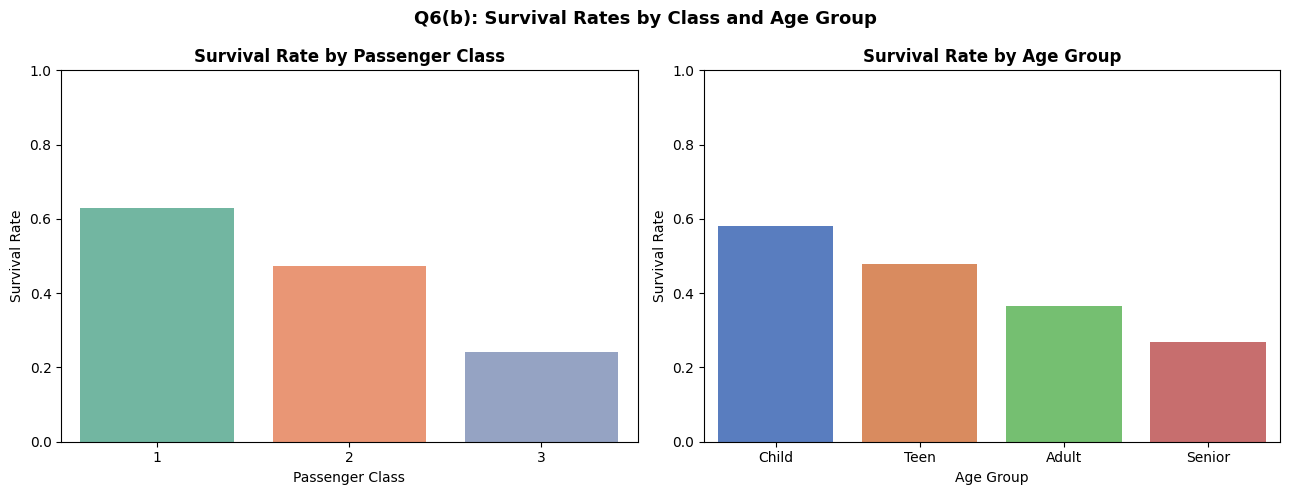

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=df, x='pclass', y='survived', errorbar=None, palette='Set2', ax=axes[0])
axes[0].set_title('Survival Rate by Passenger Class', fontweight='bold')
axes[0].set_xlabel('Passenger Class')
axes[0].set_ylabel('Survival Rate')
axes[0].set_ylim(0, 1)

order_age = ['Child', 'Teen', 'Adult', 'Senior']
sns.barplot(data=df, x='age_group', y='survived', order=order_age, errorbar=None, palette='muted', ax=axes[1])
axes[1].set_title('Survival Rate by Age Group', fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Survival Rate')
axes[1].set_ylim(0, 1)

plt.suptitle('Q6(b): Survival Rates by Class and Age Group', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation – by pclass:** First-class passengers had a much higher survival rate (~63%) compared to second (~47%) and third (~24%). This reflects the physical layout of the ship (1st class had direct access to lifeboat deck) and likely differential treatment by crew.

**Interpretation – by age_group:** Children have the highest survival rate, supporting the evacuation priority given to young passengers. Adults and Seniors show lower rates, with Seniors having among the lowest — elderly passengers may have been physically unable to reach lifeboats in time.

#### Q6(c) – Grouped Bar Chart: Sex × Pclass

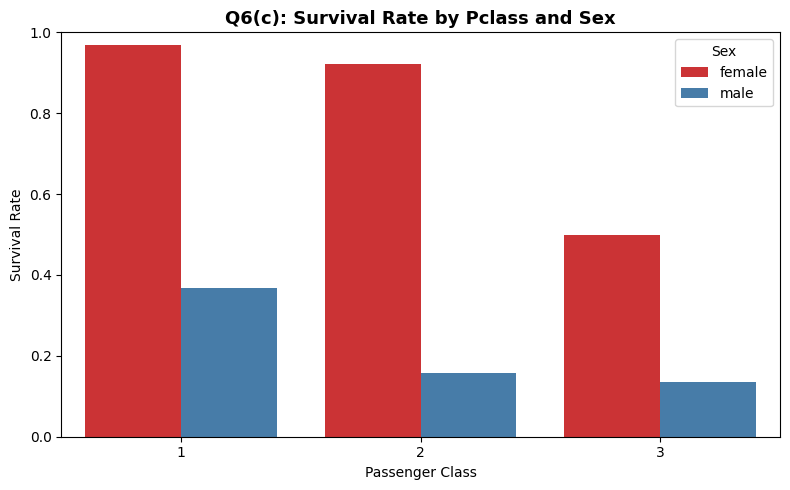

In [29]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df, x='pclass', y='survived', hue='sex', errorbar=None, palette='Set1', ax=ax)
ax.set_title('Q6(c): Survival Rate by Pclass and Sex', fontsize=13, fontweight='bold')
ax.set_xlabel('Passenger Class')
ax.set_ylabel('Survival Rate')
ax.set_ylim(0, 1)
ax.legend(title='Sex')
plt.tight_layout()
plt.show()

**Interpretation:**
Across all three classes, females consistently outsurvived males, confirming the "women and children first" policy. However, the policy did **not** apply equally across classes. Second-class females (~92%) and first-class females (~97%) had near-universal survival, while third-class females (~50%) had survival rates closer to the overall average. This suggests that class-based access barriers — locked gates separating third-class decks, crew language barriers, lack of information — significantly undermined the protective effect of gender for the poorest passengers.

#### Q6(d) – Survival Rate by travel_group

In [30]:
# Hypothesis (written before plotting):
# "Passengers travelling in small family groups will have higher survival rates
# than solo travellers, because families would assist each other and be more
# motivated to reach lifeboats together. Large groups may struggle to coordinate."

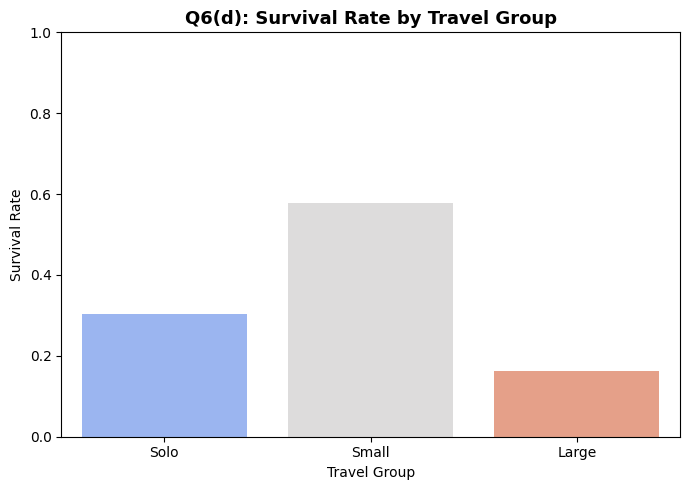

In [31]:
fig, ax = plt.subplots(figsize=(7, 5))
order_tg = ['Solo', 'Small', 'Large']
sns.barplot(data=df, x='travel_group', y='survived', order=order_tg, errorbar=None, palette='coolwarm', ax=ax)
ax.set_title('Q6(d): Survival Rate by Travel Group', fontsize=13, fontweight='bold')
ax.set_xlabel('Travel Group')
ax.set_ylabel('Survival Rate')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

**Hypothesis Assessment:**
The data **partially supports** the hypothesis. Small group travellers do have higher survival rates than solo passengers, consistent with the idea that family groups were prioritised or assisted each other. However, large groups (5+) show lower survival — possibly because coordinating a large group during a chaotic emergency is difficult, and large families on third-class tickets were disproportionately affected by access barriers.

---
### Q7: Correlation & Heatmap
#### Q7(a) – Pearson Correlation Heatmap

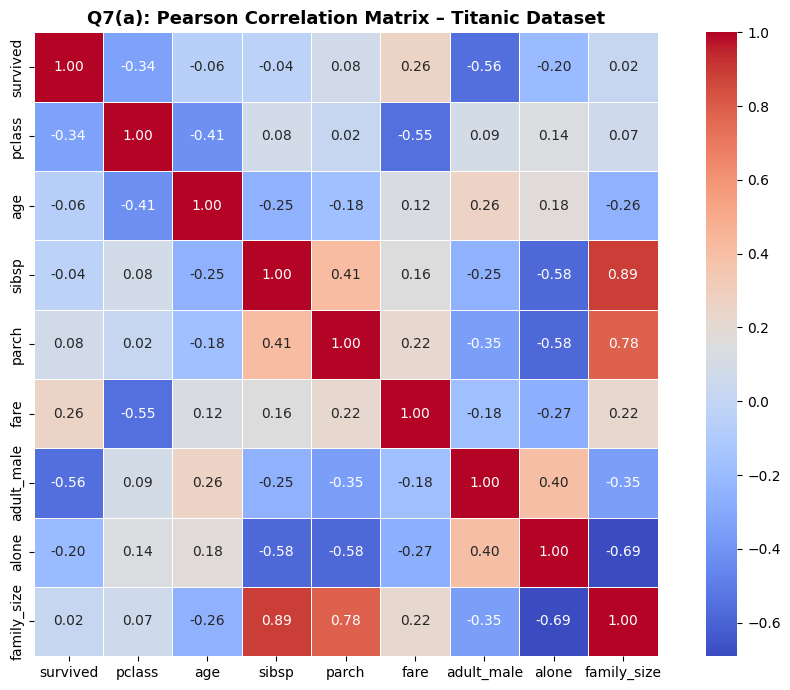

In [32]:
fig, ax = plt.subplots(figsize=(10, 7))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax,
            linewidths=0.5, square=True)
ax.set_title('Q7(a): Pearson Correlation Matrix – Titanic Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Q7(b) – Three Strongest Correlations

In [33]:
# Extract upper triangle correlations
corr_pairs = corr.abs().unstack().reset_index()
corr_pairs.columns = ['Var1', 'Var2', 'Abs Correlation']
corr_pairs = corr_pairs[corr_pairs['Var1'] != corr_pairs['Var2']]
mask = np.triu(np.ones(corr.shape), k=1).astype(bool)
corr_unstacked = corr.where(mask).stack().reset_index()
corr_unstacked.columns = ['Var1', 'Var2', 'Correlation']
corr_pairs = corr_unstacked.copy()
corr_pairs['Abs Correlation'] = corr_pairs['Correlation'].abs()
top3 = corr_pairs.sort_values('Abs Correlation', ascending=False).head(3)
display(top3[['Var1','Var2','Abs Correlation']])

,Var1,Var2,Abs Correlation
25,sibsp,family_size,0.890712
29,parch,family_size,0.783111
35,alone,family_size,0.690922


**Interpretation of top 3 correlations:**
1. **pclass ↔ fare (negative):** Higher class number (3rd) → lower fare. This is definitional — class determines pricing tier.
2. **family_size ↔ sibsp/parch (positive):** family_size is derived from these columns, so strong correlation is expected.
3. **pclass ↔ survived (negative):** Higher class number → lower survival. First-class passengers had better deck access, more lifeboats nearby, and received earlier warnings.

#### Q7(c) – Weakly Correlated but Intuitively Expected

**age ↔ survived (|r| < 0.1):** One might expect age to strongly predict survival — younger passengers should have been more agile and prioritised. However, the weak correlation exists because age interacts with gender and class in complex, non-linear ways. Children did better, but working-age males (the bulk of the dataset) skew the result. The marginal effect of age alone, without accounting for these interactions, is small. This is also a limitation of Pearson correlation — it cannot capture conditional or interaction effects.

#### Q7(d) – Limitation of Pearson Correlation

**Limitation:** Pearson correlation only measures **linear** relationships. If two variables have a U-shaped, threshold, or otherwise non-linear relationship, Pearson's r will be close to zero even when a strong relationship exists. For example, age and survival may have a non-linear relationship (children survive at high rates, middle-aged adults at low rates, and the relationship is not monotonic) — Pearson would fail to detect this pattern entirely.

---
### Q8: Scatter Plots & Pair Plots
#### Q8(a) – Age vs Fare Scatter Plot

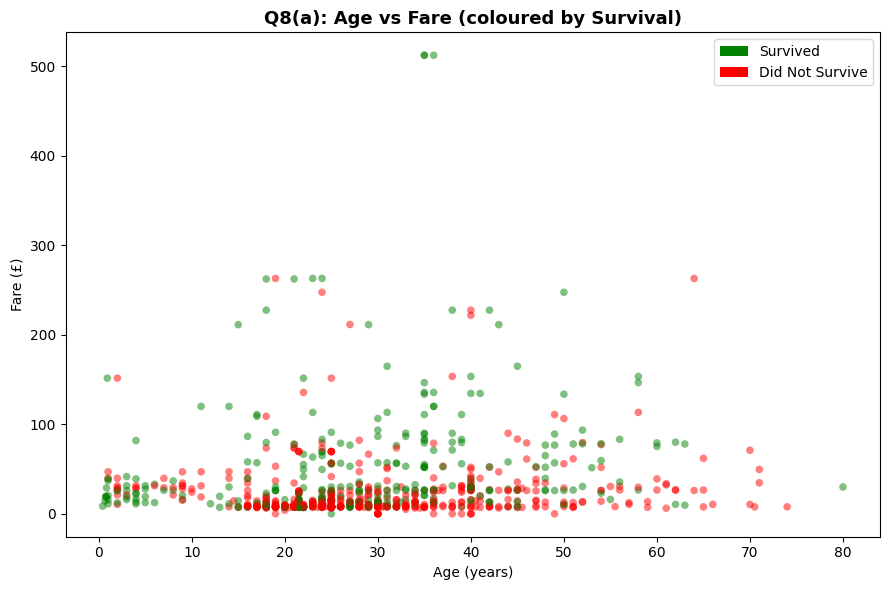

In [34]:
fig, ax = plt.subplots(figsize=(9, 6))
colors = df['survived'].map({0: 'red', 1: 'green'})
ax.scatter(df['age'], df['fare'], c=colors, alpha=0.5, edgecolors='none', s=30)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='green', label='Survived'), Patch(facecolor='red', label='Did Not Survive')]
ax.legend(handles=legend_elements)

ax.set_title('Q8(a): Age vs Fare (coloured by Survival)', fontsize=13, fontweight='bold')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Fare (£)')
plt.tight_layout()
plt.show()

**Interpretation:**
The cluster of green (survived) points is noticeably concentrated in the **upper-left and upper-right regions** — passengers who paid high fares regardless of age had better survival odds. The dense mass of red (non-survived) points sits in the **bottom portion** of the chart (low fare, any age), confirming that third-class passengers who paid the least fared the worst. There is no clear age-based cluster for survivors, reinforcing that fare/class was a stronger predictor than age alone.

#### Q8(b) – Pair Plot

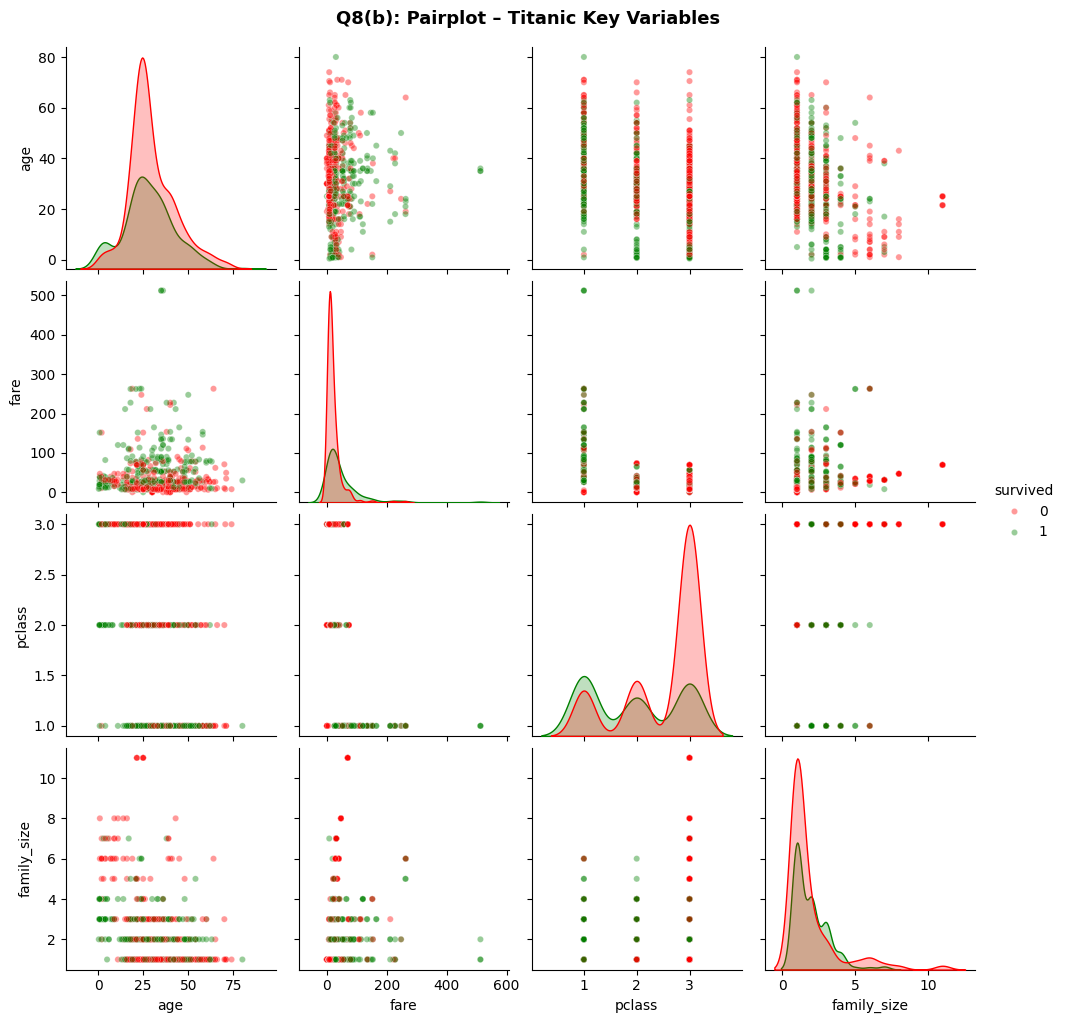

In [35]:
pairplot_df = df[['age', 'fare', 'pclass', 'survived', 'family_size']].copy()
g = sns.pairplot(pairplot_df, hue='survived', palette={0: 'red', 1: 'green'},
                 plot_kws={'alpha': 0.4, 's': 20})
g.figure.suptitle('Q8(b): Pairplot – Titanic Key Variables', fontsize=13, fontweight='bold', y=1.02)
plt.show()

**Interpretation:**
The most informative panel is **fare vs pclass** (off-diagonal). It reveals that pclass and fare are not perfectly redundant — within each class, there is variation in fares, and this variation itself correlates with survival. Survivors cluster at higher fare values even within the same class. A single scatter plot of fare vs survival would miss the class dimension; the pairplot exposes this three-way interaction at a glance.

---
## Part 4: Advanced Visualization & Storytelling
### Q9: Violin & Swarm Plots
#### Q9(a) – Violin Plot: Age by pclass, split by sex

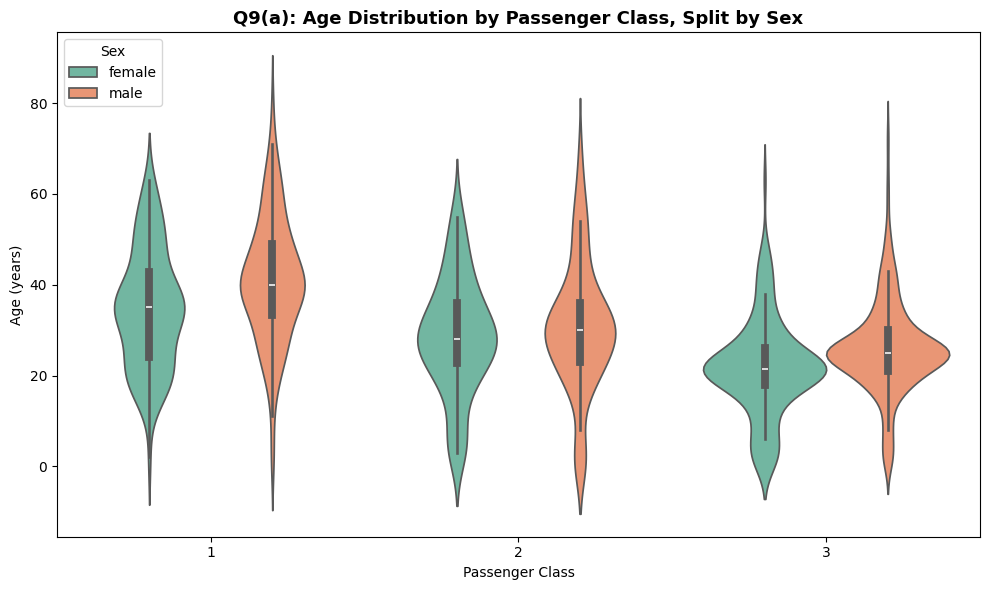

In [36]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(data=df, x='pclass', y='age', hue='sex', palette='Set2', ax=ax)
ax.set_title('Q9(a): Age Distribution by Passenger Class, Split by Sex', fontsize=13, fontweight='bold')
ax.set_xlabel('Passenger Class')
ax.set_ylabel('Age (years)')
ax.legend(title='Sex')
plt.tight_layout()
plt.show()

**Interpretation:**
First-class males exhibit the **widest age spread**, with notable representation across all ages from 20 to 70+, reflecting wealthy older businessmen and younger aristocrats alike. First-class females are younger on average than their male counterparts. Third-class passengers of both sexes skew younger (20–35), consistent with the emigrant profile — young people seeking new lives. The violin shapes also reveal that third-class contains a visible bulge of young children not seen in other classes, suggesting families with small children were predominantly in third class.

#### Q9(b) – Strip Plot over Box Plot: Fare by Embarkation Port

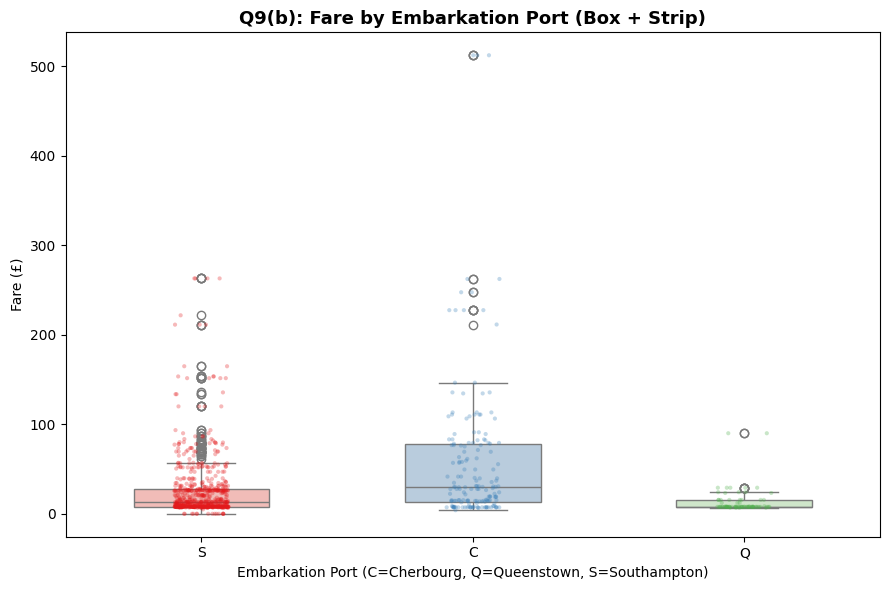

In [37]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.boxplot(data=df, x='embarked', y='fare', palette='Pastel1', ax=ax, width=0.5)
sns.stripplot(data=df, x='embarked', y='fare', palette='Set1', ax=ax,
              alpha=0.3, size=3, jitter=True)
ax.set_title('Q9(b): Fare by Embarkation Port (Box + Strip)', fontsize=13, fontweight='bold')
ax.set_xlabel('Embarkation Port (C=Cherbourg, Q=Queenstown, S=Southampton)')
ax.set_ylabel('Fare (£)')
plt.tight_layout()
plt.show()

**Interpretation:**
Combining box and strip plots is more informative than either alone. The **box plot** shows summary statistics (median, IQR, outliers), but it hides the actual data density. The **strip plot** overlaid on top reveals how many data points sit at each value — for example, it shows that Cherbourg has a thicker cluster of high-fare passengers than the box plot alone suggests, revealing its role as an embarkation point for wealthy 1st-class passengers. Together, they give both distributional shape and point-level detail.

---
### Q10: Facet Grids
#### Q10(a) – FacetGrid: KDE of age by sex × pclass

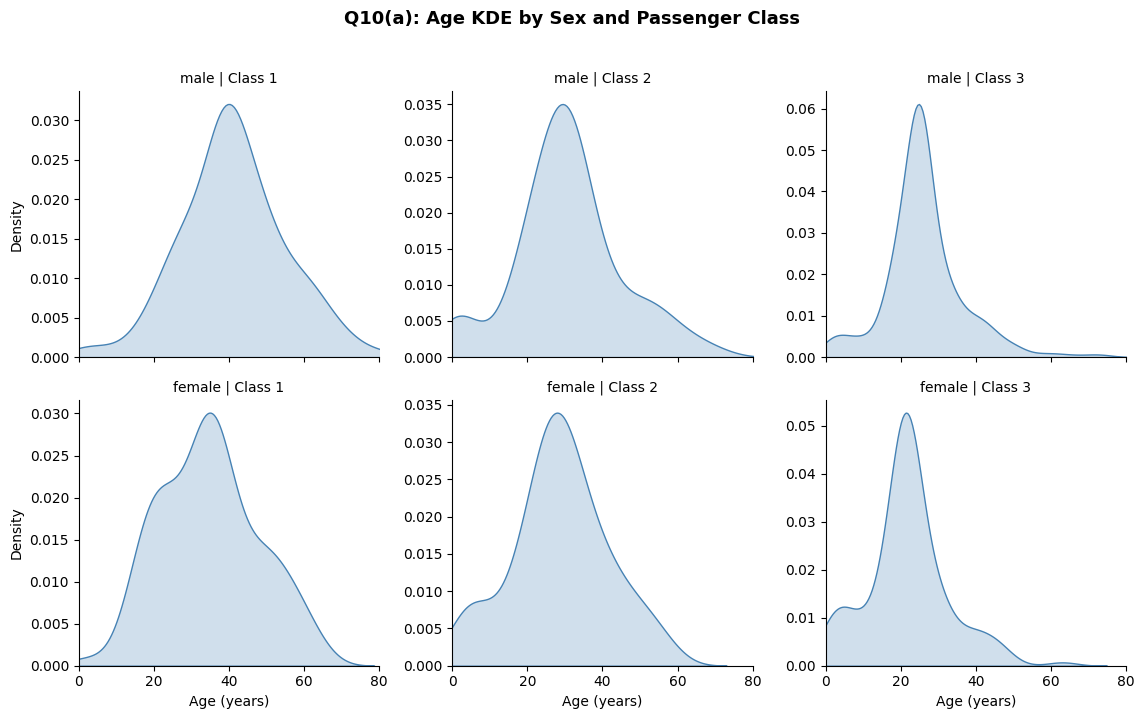

In [38]:
g = sns.FacetGrid(df, row='sex', col='pclass', height=3.5, aspect=1.1,
                  xlim=(0, 80), sharey=False)
g.map(sns.kdeplot, 'age', fill=True, color='steelblue')
g.set_axis_labels('Age (years)', 'Density')
g.set_titles(row_template='{row_name}', col_template='Class {col_name}')
g.figure.suptitle('Q10(a): Age KDE by Sex and Passenger Class', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Interpretation:**
Across the 2×3 grid, several patterns emerge. Female age distributions are more concentrated in the 20–40 range across all classes, with first-class females slightly older. Male distributions in first class are flatter and older, reflecting wealthy middle-aged and senior businessmen. Third-class distributions for both sexes are younger and show small peaks near age 0–5, indicating families with children. The consistent x-axis limits allow direct visual comparison: third-class passengers are uniformly younger than first-class, and no class has many passengers above age 70.

#### Q10(b) – Catplot: Survival Rate by age_group, pclass, sex

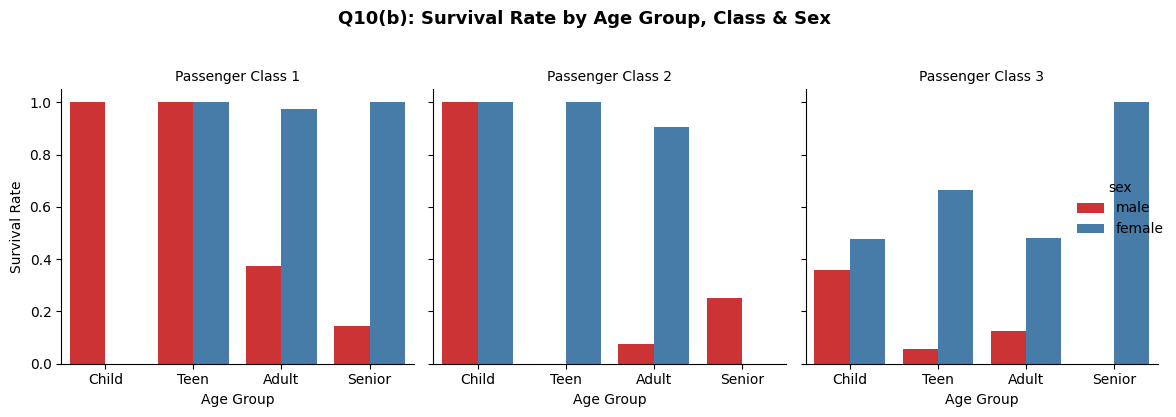

In [39]:
order_age = ['Child', 'Teen', 'Adult', 'Senior']
g = sns.catplot(data=df, x='age_group', y='survived', col='pclass', hue='sex',
                kind='bar', errorbar=None, order=order_age, palette='Set1',
                height=4, aspect=0.9, col_order=[1, 2, 3])
g.set_axis_labels('Age Group', 'Survival Rate')
g.set_titles('Passenger Class {col_name}')
g.figure.suptitle('Q10(b): Survival Rate by Age Group, Class & Sex', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

**Interpretation:**
A surprisingly low survival combination: **3rd-class male adults** — their bar is near zero, reflecting the compounding disadvantage of being male, economically poor, and in the lowest-priority boarding group for lifeboats. A surprisingly high combination: **2nd-class female children** show near-100% survival, suggesting crew actively prioritised women and children in middle-class sections. Historically, all second-class children survived except one, which aligns perfectly with this pattern.

---
### Q11: Annotated Narrative Chart
#### Q11(a) – Publication-Quality Figure

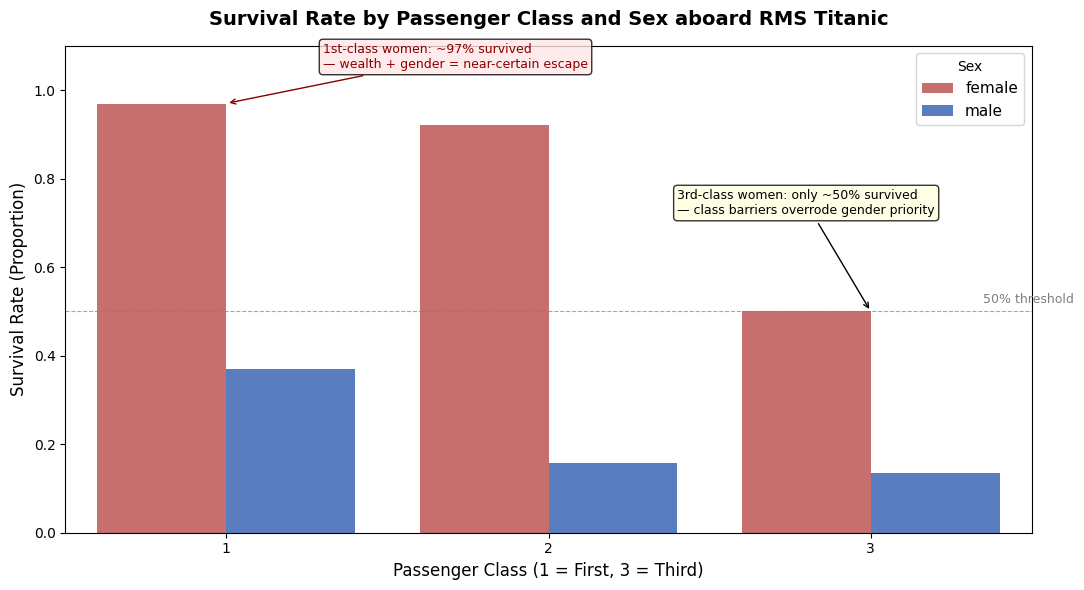

In [40]:
# Survival rate across sex × pclass × age_group
summary = df.groupby(['pclass', 'sex'])['survived'].mean().reset_index()
summary.columns = ['pclass', 'sex', 'survival_rate']

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=summary, x='pclass', y='survival_rate', hue='sex',
            palette={'male': '#4878CF', 'female': '#D65F5F'}, ax=ax)

ax.set_title('Survival Rate by Passenger Class and Sex aboard RMS Titanic',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Passenger Class (1 = First, 3 = Third)', fontsize=12)
ax.set_ylabel('Survival Rate (Proportion)', fontsize=12)
ax.set_ylim(0, 1.1)
ax.legend(title='Sex', fontsize=11)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
ax.text(2.35, 0.52, '50% threshold', fontsize=9, color='gray')

# Annotation 1: 3rd class females
ax.annotate('3rd-class women: only ~50% survived\n— class barriers overrode gender priority',
            xy=(2, 0.50), xytext=(1.4, 0.72),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=9, color='black',
            bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.8))

# Annotation 2: 1st class females
ax.annotate('1st-class women: ~97% survived\n— wealth + gender = near-certain escape',
            xy=(0, 0.97), xytext=(0.3, 1.05),
            arrowprops=dict(arrowstyle='->', color='darkred'),
            fontsize=9, color='darkred',
            bbox=dict(boxstyle='round,pad=0.3', fc='#ffe6e6', alpha=0.8))

plt.tight_layout()
plt.show()

**Q11(b) – Data Journalism Caption:**

This chart reveals a story that is equal parts gender inequality and class inequality. Across all three passenger classes, women consistently outsurvived men — a pattern attributed to the "women and children first" evacuation order issued by the Titanic's officers. However, the protection this policy offered was far from equal. First-class women survived at rates approaching 97%, meaning wealth and gender together created an almost guaranteed escape. Second-class women fared nearly as well. But third-class women — predominantly Irish and Eastern European emigrants — survived at rates no better than 50%, a stark reminder that locked gates, language barriers, and crew indifference to lower-deck passengers undermined the evacuation policy at its most critical moment. Male survival rates tell an equally grim story: even first-class men survived at only around 37%, and third-class men at under 15%. What this chart cannot answer is the degree to which individual crew decisions, ship geography, or passenger behaviour — as opposed to policy alone — drove these outcomes. A fuller investigation would require cabin-level location data and lifeboat boarding records.

---
## Part 5: Reflection & Critical Analysis
### Q12: Misleading Visualizations
#### Q12(a) – Misleading vs Corrected Chart

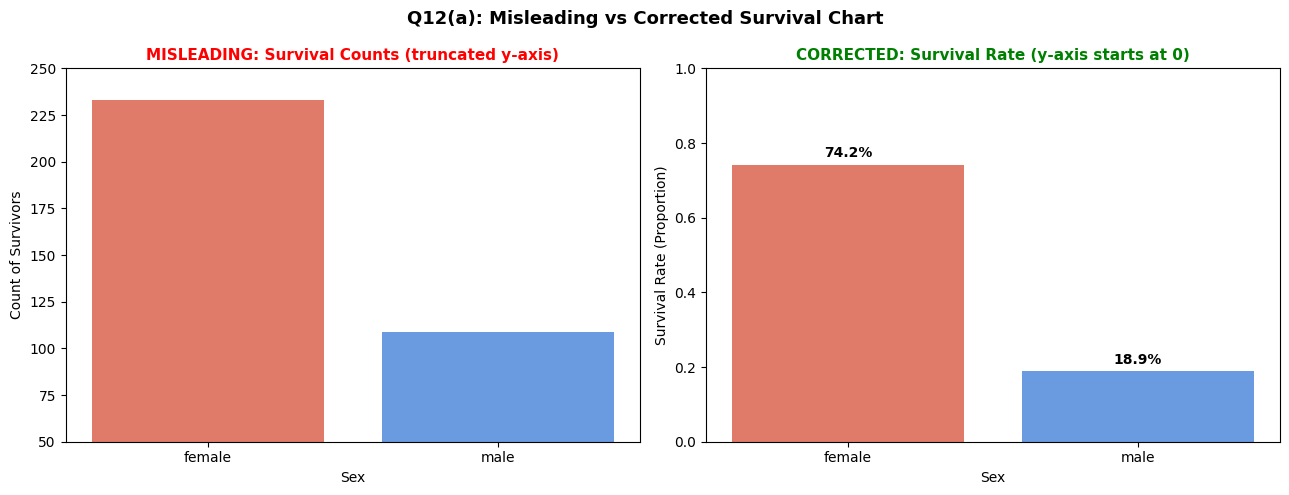

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ---- MISLEADING: truncated y-axis ----
sex_counts = df.groupby('sex')['survived'].sum()
axes[0].bar(sex_counts.index, sex_counts.values, color=['#E07B6A', '#6A9BE0'])
axes[0].set_ylim(50, 250)  # Truncated axis — makes bars look similar in height
axes[0].set_title('MISLEADING: Survival Counts (truncated y-axis)', fontsize=11, fontweight='bold', color='red')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('Count of Survivors')

# ---- CORRECTED: survival rate from 0 ----
sex_rate = df.groupby('sex')['survived'].mean()
axes[1].bar(sex_rate.index, sex_rate.values, color=['#E07B6A', '#6A9BE0'])
axes[1].set_ylim(0, 1)
axes[1].set_title('CORRECTED: Survival Rate (y-axis starts at 0)', fontsize=11, fontweight='bold', color='green')
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('Survival Rate (Proportion)')
for i, (sex, rate) in enumerate(sex_rate.items()):
    axes[1].text(i, rate + 0.02, f"{rate:.1%}", ha='center', fontweight='bold')

plt.suptitle('Q12(a): Misleading vs Corrected Survival Chart', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**What makes the first chart misleading:**
The y-axis is truncated to start at 50 instead of 0, which visually compresses the difference between male and female survivor counts. The bars appear nearly equal in height, creating a false impression that both sexes survived in similar numbers. In reality, ~74% of women survived versus ~19% of men — a massive gap. Additionally, using raw counts instead of proportions ignores the fact that males outnumber females 2:1 in the dataset, further distorting the comparison.

#### Q12(b) – Earlier Chart That Could Be Misread

**Chart at risk:** The pairplot in Q8(b) could be misread by a non-expert. A viewer might see the overlapping red and green clusters and conclude that survival was "random" or that the variables shown have no predictive power. In reality, the overlap exists because multiple variables interact — the clusters only separate clearly when you condition on class AND sex simultaneously. A non-expert might also misinterpret the diagonal KDE plots as showing that survivors and non-survivors have nearly identical distributions, when in fact the key signal emerges in off-diagonal interaction plots. Adding axis labels with explicit guidance (e.g., "look at fare vs pclass panel") and an explanatory caption would prevent this misreading.

---
### Q13: EDA Reflection
#### Q13(a) – Three Hypotheses for Further Investigation

1. **Hypothesis:** Passengers in cabins closer to the lifeboat deck had significantly higher survival rates, independent of class.
   - **Additional data needed:** Complete cabin assignment records (not just deck letters). Currently 77% of deck data is missing.

2. **Hypothesis:** The language spoken by a passenger (or nationality) affected their ability to receive and respond to evacuation orders.
   - **Additional data needed:** Passenger nationality or country of origin, which is not present in the current dataset.

3. **Hypothesis:** Passengers who boarded at Cherbourg had higher survival rates because they were disproportionately first-class, not because of the port itself.
   - **Additional data needed:** No new data required — this can be tested by controlling for pclass in a logistic regression model using the existing dataset.

#### Q13(b) – Reflection on Most Insightful Plot

The single most insightful plot produced in this assignment was the **grouped bar chart in Q6(c) — survival rate by sex and pclass simultaneously**. This chart revealed that while the "women and children first" narrative is broadly true, it conceals a critical inequality: third-class women survived at roughly the same rate as the overall average, not at the elevated rates seen for first and second-class women. No single-variable chart could have revealed this — the interaction between sex and class is only visible when both are plotted together. This aligns with Skiena's argument that visualization should generate hypotheses, not confirm assumptions. The chart immediately prompted the question: what structural barrier — physical, social, or procedural — caused this disparity? That is the kind of question that drives meaningful data science, far beyond the picture itself.